# P-NET

## Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
import random
import gc

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
sys.path.insert(0, PROJECT_ROOT)

import pickle
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from palettable import wesanderson as wes

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import KNNImputer

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

from MAIN.utils import *
from MAIN.train import *
from MAIN.reactome import ReactomeNetwork
from MAIN.Pnet import MaskedLinear, PNET
from MAIN.interpret import interpret, evaluate_interpret_save, visualize_importances

from implementations_pnet import *
from utility import *

data_dir = "../data/TCGA-BRCA/"

Torch version: 2.9.1+cpu
CUDA available: False


c:\Users\Travail\anaconda3\envs\pnet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.9.1+cpu
CUDA available: False


## Data loading and preprocessing

In [2]:
#Load all omics and their metadatas
data_dir = "../data/TCGA-BRCA/"
mod = ["mRNA", "DNAm" , "RPPA"]

data = {}
for omic in mod :
 with open(f"{data_dir}{omic}.pkl", "rb") as f:  # 'rb' = read binary
    data[omic] = pickle.load(f)

mRNA_expr = data['mRNA']['expr']
mRNA_meta = data['mRNA']['meta']
DNAm_expr = data['DNAm']['expr']
DNAm_meta = data['DNAm']['meta']
RPPA_expr = data['RPPA']['expr']
RPPA_meta = data['RPPA']['meta']

In [3]:
#Put together meta data off patients from all omics
df_all_meta = pd.concat([mRNA_meta,DNAm_meta,RPPA_meta], ignore_index=False)
df_all_meta = df_all_meta.drop_duplicates(subset="patient")

In [ ]:
# Create folds for cross-validation
folds = create_stratified_folds(
    df_all_meta,
    stratify_col="paper_BRCA_Subtype_PAM50"
)

Fold 1 (size=132):
paper_BRCA_Subtype_PAM50
LumA     0.530303
LumB     0.212121
Basal    0.181818
Her2     0.075758
Name: proportion, dtype: float64
----------------------------------------
Fold 2 (size=132):
paper_BRCA_Subtype_PAM50
LumA     0.530303
LumB     0.212121
Basal    0.181818
Her2     0.075758
Name: proportion, dtype: float64
----------------------------------------
Fold 3 (size=132):
paper_BRCA_Subtype_PAM50
LumA     0.537879
LumB     0.212121
Basal    0.174242
Her2     0.075758
Name: proportion, dtype: float64
----------------------------------------
Fold 4 (size=131):
paper_BRCA_Subtype_PAM50
LumA     0.541985
LumB     0.206107
Basal    0.183206
Her2     0.068702
Name: proportion, dtype: float64
----------------------------------------
Fold 5 (size=131):
paper_BRCA_Subtype_PAM50
LumA     0.534351
LumB     0.206107
Basal    0.183206
Her2     0.076336
Name: proportion, dtype: float64
----------------------------------------


In [ ]:
# Create omics subsets based on stratified folds.
mRNA_exprs, DNAm_exprs, RPPA_exprs, all_metas = create_subsets_from_fold(df_all_meta,mRNA_expr, DNAm_expr, RPPA_expr,folds)

## Crossvalidation

### With missing values dropped

In [6]:
models,train_loaders,test_loaders,mapping,model_features =  build_k_PNET_models(mRNA_exprs, DNAm_exprs, RPPA_exprs, df_all_meta,'drop')

Epoch 200: 100%|██████████| 200/200 [01:22<00:00,  2.42epoch/s, loss=0.00515] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:09<00:00,  2.89epoch/s, loss=0.0106]  


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:17<00:00,  2.59epoch/s, loss=0.0361]  


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:22<00:00,  2.44epoch/s, loss=2.09e-5] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:21<00:00,  2.45epoch/s, loss=0.00624] 


Training complete.


In [7]:
reports,accuracies,f1_scores = commute_PNET_metrics(models,test_loaders)

In [8]:
test_reports_sum = sum(reports) / len(reports)
print(f'Average f1-score:{np.mean(f1_scores)} ± {np.std(f1_scores)}')
print(f'Average accuracy:{np.mean(accuracies)} ± {np.std(accuracies)}')
print('Best Model:',np.argmax(f1_scores))
test_reports_sum

Average f1-score:0.7967043298469075 ± 0.041603537719071784
Average accuracy:0.820039371259948 ± 0.034013408276515944
Best Model: 4


,precision,recall,f1-score,support
Basal,0.983333,0.892331,0.933437,12.200000
Her2,0.893333,0.701667,0.773333,5.600000
LumA,0.864402,0.885027,0.872357,46.000000
LumB,0.604675,0.633333,0.607691,16.400000
accuracy,0.820039,0.820039,0.820039,0.820039
macro avg,0.836436,0.778089,0.796704,80.200000
weighted avg,0.832226,0.820039,0.820539,80.200000


In [10]:
summary_drop = construct_sumary_dataframe(accuracies,f1_scores,reports,'Drop','P-NET')
summary_drop

,0,1,2,3,4,mean,std,model,missing_value_imputation_method
Accuracy,0.772152,0.816092,0.816092,0.817073,0.878788,0.820039,0.038028,P-NET,Drop
Macro F1,0.762204,0.754419,0.773124,0.840434,0.853340,0.796704,0.046514,P-NET,Drop
Basal F1,0.869565,0.916667,0.928571,0.952381,1.000000,0.933437,0.047891,P-NET,Drop
Her2 F1,0.800000,0.666667,0.666667,0.933333,0.800000,0.773333,0.111555,P-NET,Drop
LumA F1,0.838710,0.888889,0.868687,0.844444,0.921053,0.872357,0.033798,P-NET,Drop
LumB F1,0.540541,0.545455,0.628571,0.631579,0.692308,0.607691,0.064322,P-NET,Drop


### Imputation by medians

In [11]:
models,train_loaders,test_loaders,mapping,model_features =  build_k_PNET_models(mRNA_exprs, DNAm_exprs, RPPA_exprs, df_all_meta,'median')

Epoch 200: 100%|██████████| 200/200 [01:55<00:00,  1.73epoch/s, loss=0.116] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:49<00:00,  1.83epoch/s, loss=0.145]


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:38<00:00,  2.04epoch/s, loss=0.56]  


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:44<00:00,  1.92epoch/s, loss=0.478] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [02:05<00:00,  1.59epoch/s, loss=0.0914]


Training complete.


In [12]:
reports,accuracies,f1_scores = commute_PNET_metrics(models,test_loaders)

In [13]:
test_reports_sum = sum(reports) / len(reports)
print(f'Average f1-score:{np.mean(f1_scores)} ± {np.std(f1_scores)}')
print(f'Average accuracy:{np.mean(accuracies)} ± {np.std(accuracies)}')
print('Best Model:',np.argmax(f1_scores))
test_reports_sum

Average f1-score:0.8108575571737962 ± 0.033960815203418364
Average accuracy:0.8388965995836225 ± 0.02387264151137376
Best Model: 4


,precision,recall,f1-score,support
Basal,0.944151,0.932971,0.936878,23.800000
Her2,0.820635,0.715556,0.758142,9.800000
LumA,0.845000,0.906398,0.873918,70.400000
LumB,0.736076,0.629630,0.674492,27.600000
accuracy,0.838897,0.838897,0.838897,0.838897
macro avg,0.836466,0.796139,0.810858,131.600000
weighted avg,0.838283,0.838897,0.834835,131.600000


In [14]:
summary_median = construct_sumary_dataframe(accuracies,f1_scores,reports,'median','P-NET')
summary_median

,0,1,2,3,4,mean,std,model,missing_value_imputation_method
Accuracy,0.825758,0.856061,0.840909,0.801527,0.870229,0.838897,0.026690,P-NET,median
Macro F1,0.785869,0.811816,0.844256,0.761553,0.850794,0.810858,0.037969,P-NET,median
Basal F1,0.901961,0.936170,0.977778,0.888889,0.979592,0.936878,0.041893,P-NET,median
Her2 F1,0.705882,0.705882,0.842105,0.736842,0.800000,0.758142,0.060658,P-NET,median
LumA F1,0.868966,0.899329,0.857143,0.855263,0.888889,0.873918,0.019518,P-NET,median
LumB F1,0.666667,0.705882,0.700000,0.565217,0.734694,0.674492,0.065693,P-NET,median


### Imputation by kNN

In [15]:
models,train_loaders,test_loaders,mapping,model_features =  build_k_PNET_models(mRNA_exprs, DNAm_exprs, RPPA_exprs, df_all_meta,'KNN')

Epoch 200: 100%|██████████| 200/200 [02:12<00:00,  1.51epoch/s, loss=0.137] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:55<00:00,  1.74epoch/s, loss=0.164] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [02:03<00:00,  1.62epoch/s, loss=0.445] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:40<00:00,  1.99epoch/s, loss=0.162] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:48<00:00,  1.84epoch/s, loss=0.158] 


Training complete.


In [16]:
reports,accuracies,f1_scores = commute_PNET_metrics(models,test_loaders)

In [17]:
test_reports_sum = sum(reports) / len(reports)
print(f'Average f1-score:{np.mean(f1_scores)} ± {np.std(f1_scores)}')
print(f'Average accuracy:{np.mean(accuracies)} ± {np.std(accuracies)}')
print('Best Model:',np.argmax(f1_scores))
test_reports_sum

Average f1-score:0.7862853030023984 ± 0.036231495284472996
Average accuracy:0.8039555863983345 ± 0.03380164673113846
Best Model: 4


,precision,recall,f1-score,support
Basal,0.965217,0.916304,0.939669,23.800000
Her2,0.874301,0.737778,0.768460,9.800000
LumA,0.829627,0.858310,0.843027,70.400000
LumB,0.595466,0.594444,0.593985,27.600000
accuracy,0.803956,0.803956,0.803956,0.803956
macro avg,0.816153,0.776709,0.786285,131.600000
weighted avg,0.808548,0.803956,0.802511,131.600000


In [18]:
summary_KNN = construct_sumary_dataframe(accuracies,f1_scores,reports,'KNN','P-NET')
summary_KNN

,0,1,2,3,4,mean,std,model,missing_value_imputation_method
Accuracy,0.787879,0.840909,0.780303,0.763359,0.847328,0.803956,0.037791,P-NET,KNN
Macro F1,0.733060,0.814017,0.787274,0.762065,0.835010,0.786285,0.040508,P-NET,KNN
Basal F1,0.893617,0.933333,0.977778,0.893617,1.000000,0.939669,0.048409,P-NET,KNN
Her2 F1,0.571429,0.777778,0.869565,0.800000,0.823529,0.768460,0.115280,P-NET,KNN
LumA F1,0.835616,0.890411,0.811189,0.802920,0.875000,0.843027,0.038551,P-NET,KNN
LumB F1,0.631579,0.654545,0.490566,0.551724,0.641509,0.593985,0.070393,P-NET,KNN


### Put together all performance metrics and save

In [19]:
summary = pd.concat([summary_drop,summary_median,summary_KNN], axis=0)
summary.head(18)

,0,1,2,3,4,mean,std,model,missing_value_imputation_method
Accuracy,0.772152,0.816092,0.816092,0.817073,0.878788,0.820039,0.038028,P-NET,Drop
Macro F1,0.762204,0.754419,0.773124,0.840434,0.853340,0.796704,0.046514,P-NET,Drop
Basal F1,0.869565,0.916667,0.928571,0.952381,1.000000,0.933437,0.047891,P-NET,Drop
Her2 F1,0.800000,0.666667,0.666667,0.933333,0.800000,0.773333,0.111555,P-NET,Drop
LumA F1,0.838710,0.888889,0.868687,0.844444,0.921053,0.872357,0.033798,P-NET,Drop
LumB F1,0.540541,0.545455,0.628571,0.631579,0.692308,0.607691,0.064322,P-NET,Drop
Accuracy,0.825758,0.856061,0.840909,0.801527,0.870229,0.838897,0.026690,P-NET,median
Macro F1,0.785869,0.811816,0.844256,0.761553,0.850794,0.810858,0.037969,P-NET,median
Basal F1,0.901961,0.936170,0.977778,0.888889,0.979592,0.936878,0.041893,P-NET,median
Her2 F1,0.705882,0.705882,0.842105,0.736842,0.800000,0.758142,0.060658,P-NET,median


In [ ]:
summary.to_csv("PNET_results.csv", index=True)

## Interpretation

In [21]:
models,train_loaders,test_loaders,mapping,model_features =  build_k_PNET_models(mRNA_exprs, DNAm_exprs, RPPA_exprs, df_all_meta,'drop')

Epoch 200: 100%|██████████| 200/200 [01:03<00:00,  3.15epoch/s, loss=0.00515] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:01<00:00,  3.27epoch/s, loss=0.0106]  


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:04<00:00,  3.11epoch/s, loss=0.0361]  


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:09<00:00,  2.86epoch/s, loss=2.09e-5] 


Training complete.


Epoch 200: 100%|██████████| 200/200 [01:30<00:00,  2.22epoch/s, loss=0.00624] 


Training complete.


In [22]:
reports,accuracies,f1_scores = commute_PNET_metrics(models,test_loaders)

In [23]:
test_reports_sum = sum(reports) / len(reports)
print('Average f1-score:',np.mean(f1_scores))
print('Average accuracy:',np.mean(accuracies))
print('Best Model:',np.argmax(f1_scores))
test_reports_sum

Average f1-score: 0.7967043298469075
Average accuracy: 0.820039371259948
Best Model: 4


,precision,recall,f1-score,support
Basal,0.983333,0.892331,0.933437,12.200000
Her2,0.893333,0.701667,0.773333,5.600000
LumA,0.864402,0.885027,0.872357,46.000000
LumB,0.604675,0.633333,0.607691,16.400000
accuracy,0.820039,0.820039,0.820039,0.820039
macro avg,0.836436,0.778089,0.796704,80.200000
weighted avg,0.832226,0.820039,0.820539,80.200000


In [ ]:
# Set global font size for all text elements
plt.rcParams['font.size'] = 14

# Customize specific elements
plt.rcParams['axes.labelsize'] = 20  # Font size for axis labels
plt.rcParams['axes.titlesize'] = 20  # Font size for plot titles
plt.rcParams['xtick.labelsize'] = 10  # Font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 10  # Font size for y-axis tick labels
plt.rcParams['legend.fontsize'] = 12  # Font size for legend text

# Other common customizations
plt.rcParams['figure.figsize'] = (10, 6)  # Default figure size (width, height in inches)
plt.rcParams['axes.grid'] = True  # Enable grid lines
plt.rcParams['grid.alpha'] = 0.5  # Grid transparency
plt.rcParams['axes.facecolor'] = 'white'  # Background color for plot area

sns.set_style("whitegrid")
sns.set_palette("colorblind")

Save Path Not Found - Plots will not be saved


c:\Users\Travail\anaconda3\envs\pnet\lib\site-packages\captum\attr\_core\deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
c:\Users\Travail\anaconda3\envs\pnet\lib\site-packages\captum\log\dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


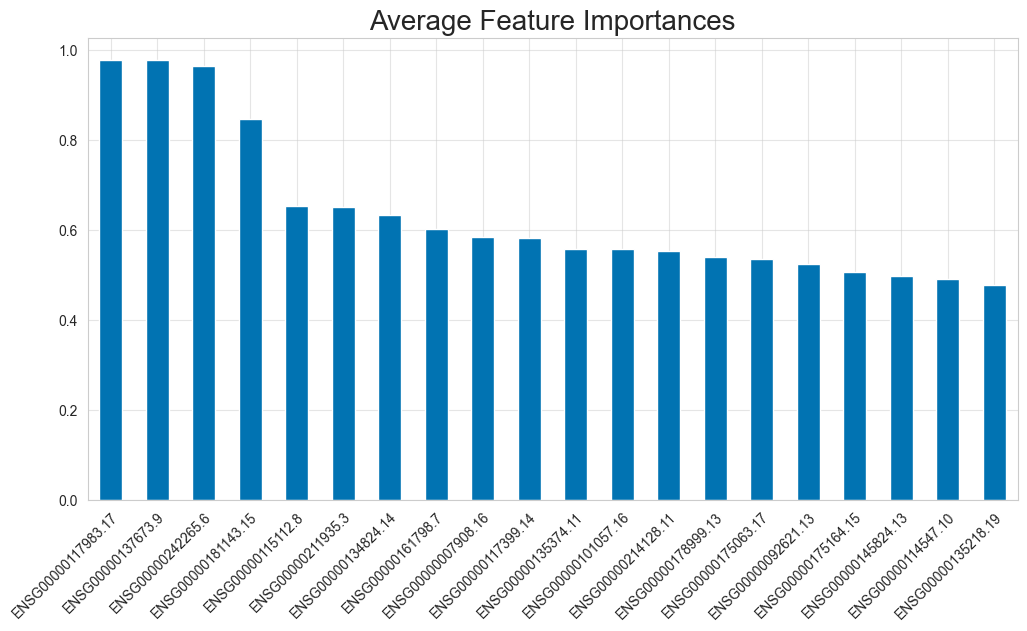

Linear(in_features=4464, out_features=723, bias=True)
MaskedLinear(in_features=723, out_features=1613, bias=True)
MaskedLinear(in_features=1613, out_features=1107, bias=True)
MaskedLinear(in_features=1107, out_features=488, bias=True)
MaskedLinear(in_features=488, out_features=159, bias=True)
MaskedLinear(in_features=159, out_features=28, bias=True)


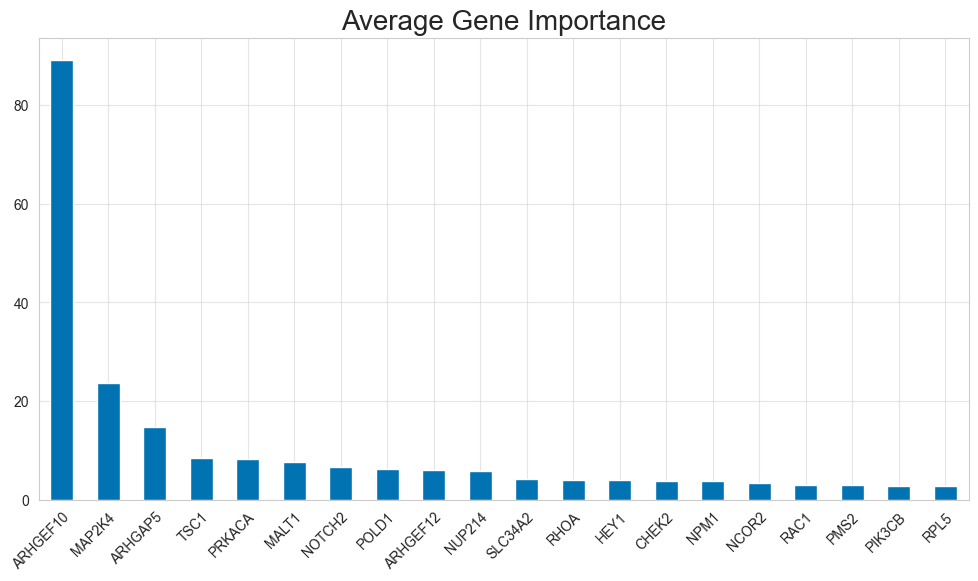

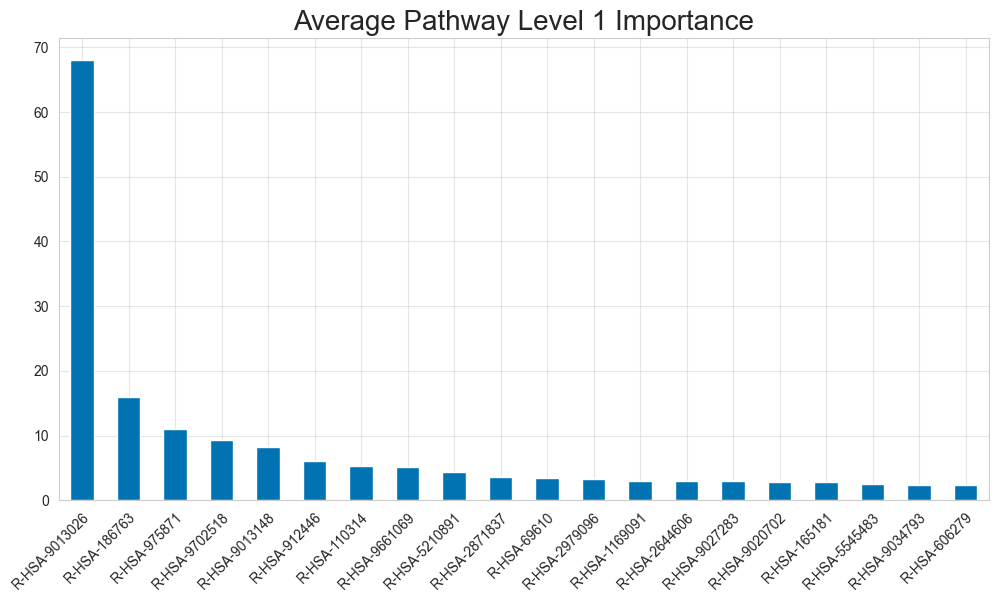

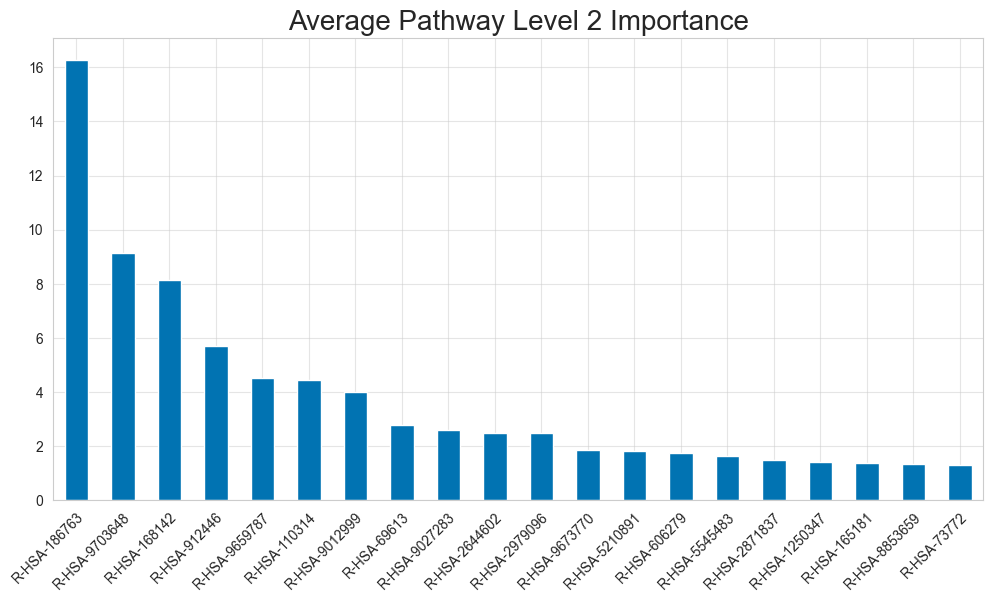

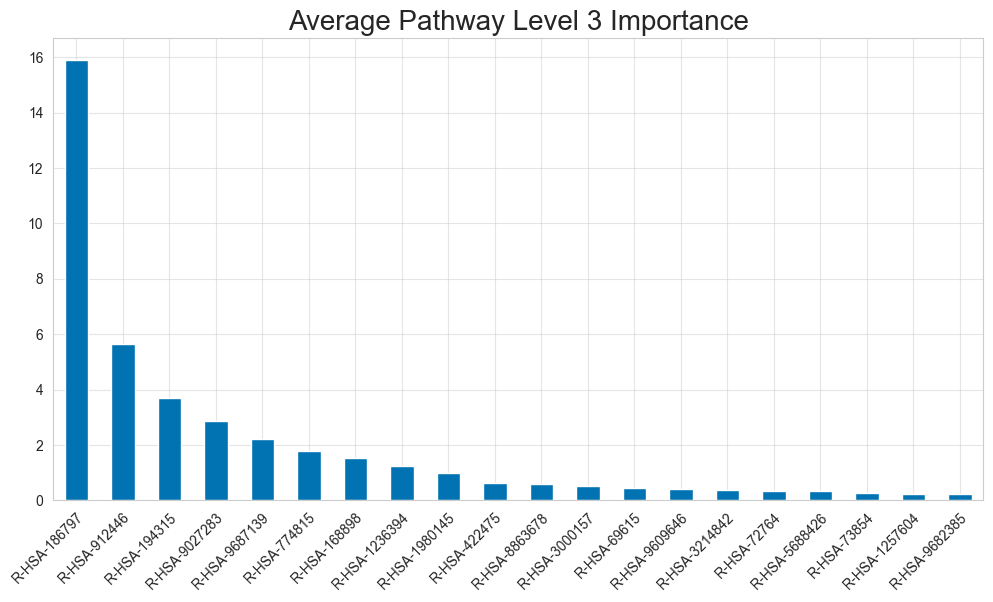

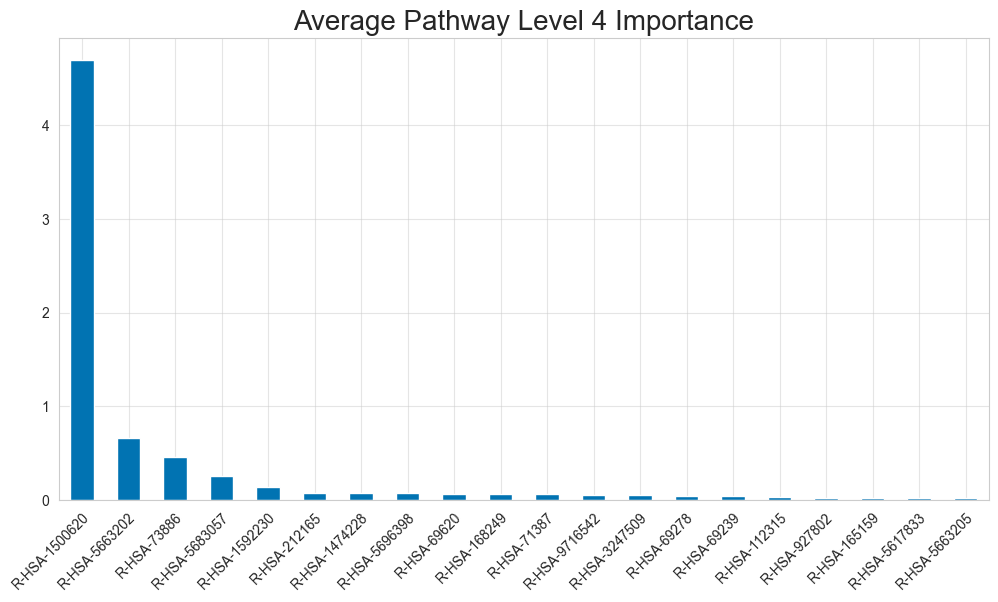

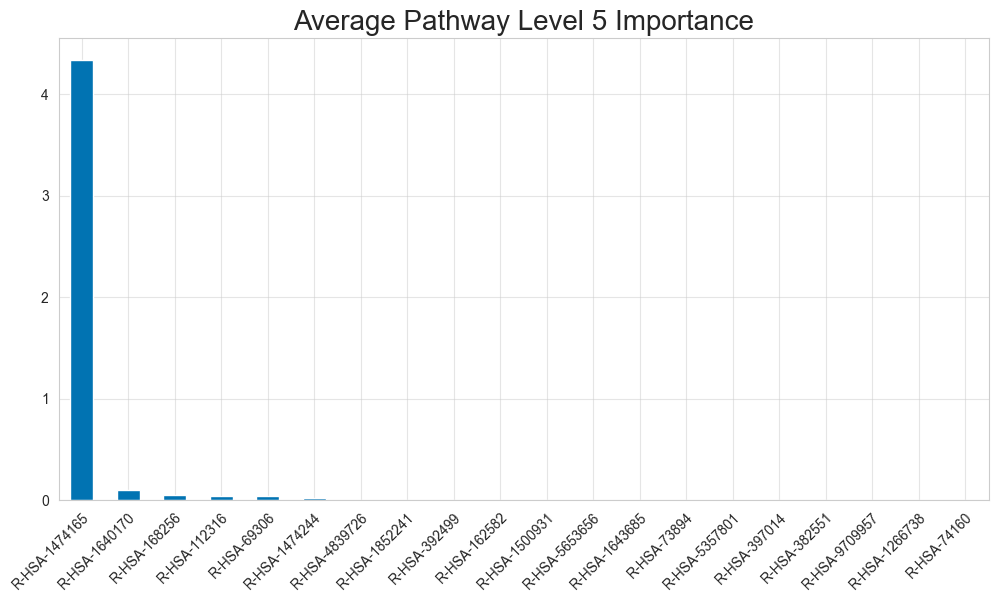

In [25]:
# This code extracts the complete test dataset from the 5th test DataLoader,
# runs the model on the full set in a single forward pass, and computes
# interpretation scores for the resulting predictions.

# Extract all data and target batches from test_loaders[4].
# Each element of the DataLoader yields a (data, target) pair, so we collect
# all of them using a list comprehension, then unzip them into two tuples:
# one containing all data tensors, the other all target tensors.
data_batches, target_batches = zip(*[(data, target) for data, target in test_loaders[4]])

# Concatenate all data batches into a single tensor containing the full test set.
# The same is done for the target batches to obtain the full set of true labels.
test_data = torch.cat(data_batches, dim=0).to('cpu') # Interpretability has to be done on CPU
test_targets = torch.cat(target_batches, dim=0).to('cpu')

# Assign to the model the feature list corresponding to the 5th fold.
# This is typically required by the interpretation method, which expects the model
# to expose the feature representations associated with this fold.
model = models[4].to('cpu')
model.features = model_features[4]

# Switch the model to evaluation mode and perform inference on the entire test dataset.
model.eval()
with torch.no_grad():
    # Forward pass on all test samples at once.
    logits = model(test_data)
    # Derive predicted class indices by selecting the maximal logit for each sample.
    test_pred = torch.argmax(logits, dim=1)

# Compute interpretation/importance scores for the predictions.
# The `interpret` function uses the trained model, the full test data,
# and the predicted labels. Setting `savedir='None'` prevents saving outputs to disk.
model_importances = interpret(model.eval(), test_data, test_pred, savedir='None')


Allows visualization of the features that drive tumor subtype prediction at each layer: Layer 1 (input omic features), Layer 2 (genes), and Layers 3–5 (pathways).